In [2]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

plt.rcParams['figure.dpi'] = 200


In [3]:
ds = pd.read_csv ('PlayTennis.csv')

display(ds)

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes
5,rainy,cool,normal,True,no
6,overcast,cool,normal,True,yes
7,sunny,mild,high,False,no
8,sunny,cool,normal,False,yes
9,rainy,mild,normal,False,yes


In [8]:
model = DecisionTreeClassifier(min_samples_leaf=1)

X = ds.drop(['play'], axis=1)
Y = ds['play']=='yes'

le_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X = X.copy()
X_transformed = le_transformer.fit_transform(X)

print (X_transformed)

X_transformed = pd.DataFrame()
for col in X.columns:
    unique_values = X[col].unique()
    if (len(unique_values) > 2):
        for val in unique_values:
            X_transformed[f'{col}_is_{val}'] = ds[col] == val
    else:
        X_transformed[f'{col}_is_{unique_values[0]}'] = ds[col] == unique_values[0]

X_transformed['windy_is_False'][[3,4,6]] = np.nan
display(X_transformed)

model.fit(X_transformed, Y)

Y_predicted = model.predict(X_transformed)


[[0. 0. 1. 0. 1. 0. 1. 0. 1. 0.]
 [0. 0. 1. 0. 1. 0. 1. 0. 0. 1.]
 [1. 0. 0. 0. 1. 0. 1. 0. 1. 0.]
 [0. 1. 0. 0. 0. 1. 1. 0. 1. 0.]
 [0. 1. 0. 1. 0. 0. 0. 1. 1. 0.]
 [0. 1. 0. 1. 0. 0. 0. 1. 0. 1.]
 [1. 0. 0. 1. 0. 0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 0. 1. 1. 0. 1. 0.]
 [0. 0. 1. 1. 0. 0. 0. 1. 1. 0.]
 [0. 1. 0. 0. 0. 1. 0. 1. 1. 0.]
 [0. 0. 1. 0. 0. 1. 0. 1. 0. 1.]
 [1. 0. 0. 0. 0. 1. 1. 0. 0. 1.]
 [1. 0. 0. 0. 1. 0. 0. 1. 1. 0.]
 [0. 1. 0. 0. 0. 1. 1. 0. 0. 1.]]


C:\Users\mvar9\AppData\Local\Temp\ipykernel_5028\2057814663.py:22: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_transformed['windy_is_False'][[3,4,6]] = np.nan
C:\Users\mvar9\AppData\Local\Temp\ipykernel_5028\2057814663.py:22: FutureWarni

,outlook_is_sunny,outlook_is_overcast,outlook_is_rainy,temp_is_hot,temp_is_mild,temp_is_cool,humidity_is_high,windy_is_False
0,True,False,False,True,False,False,True,True
1,True,False,False,True,False,False,True,False
2,False,True,False,True,False,False,True,True
3,False,False,True,False,True,False,True,NaN
4,False,False,True,False,False,True,False,NaN
5,False,False,True,False,False,True,False,False
6,False,True,False,False,False,True,False,NaN
7,True,False,False,False,True,False,True,True
8,True,False,False,False,False,True,False,True
9,False,False,True,False,True,False,False,True


In [9]:
from sklearn.metrics import confusion_matrix
confusion_matrix(Y, Y_predicted)

array([[5, 0],
       [0, 9]], dtype=int64)

[Text(0.6666666666666666, 0.9, 'outlook_is_overcast <= 0.5\ngini = 0.459\nsamples = 14\nvalue = [5, 9]\nclass = y[1]'),
 Text(0.5555555555555556, 0.7, 'humidity_is_high <= 0.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]\nclass = y[0]'),
 Text(0.6111111111111112, 0.8, 'True  '),
 Text(0.3333333333333333, 0.5, 'windy_is_False <= 0.5\ngini = 0.32\nsamples = 5\nvalue = [1, 4]\nclass = y[1]'),
 Text(0.2222222222222222, 0.3, 'outlook_is_sunny <= 0.5\ngini = 0.5\nsamples = 2\nvalue = [1, 1]\nclass = y[0]'),
 Text(0.1111111111111111, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = y[0]'),
 Text(0.3333333333333333, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = y[1]'),
 Text(0.4444444444444444, 0.3, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]\nclass = y[1]'),
 Text(0.7777777777777778, 0.5, 'windy_is_False <= inf\ngini = 0.32\nsamples = 5\nvalue = [4, 1]\nclass = y[0]'),
 Text(0.6666666666666666, 0.3, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]\nclass = y[0]'),
 Text(0.8888888888888888, 0

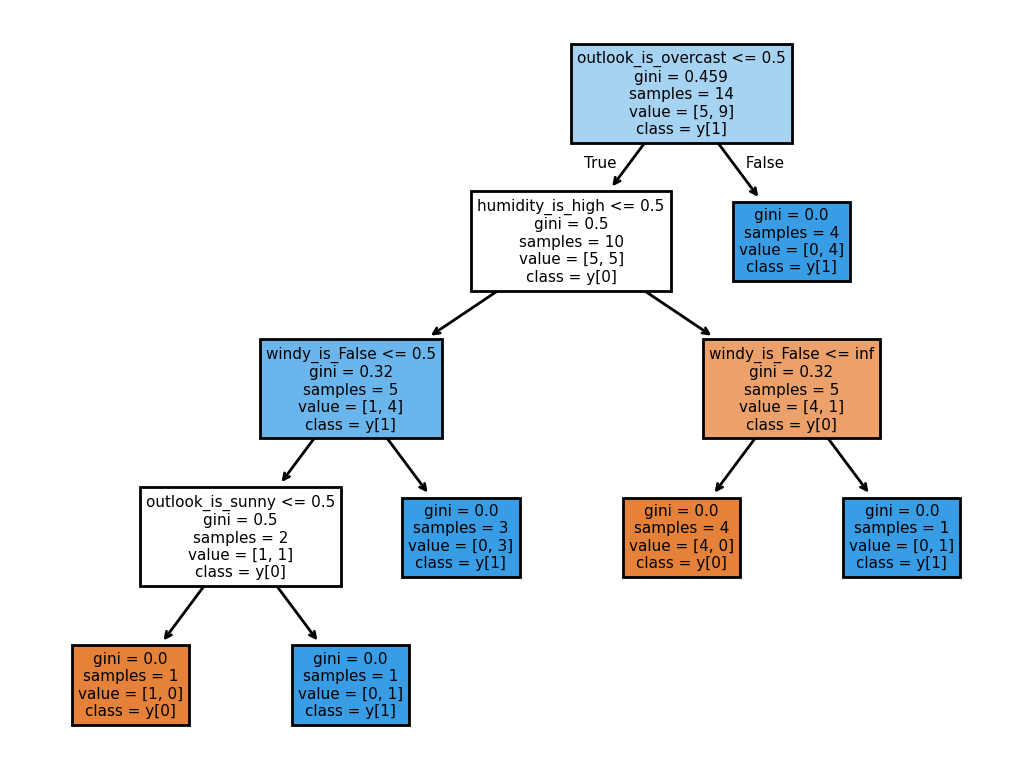

In [10]:
plt.figure()
tree.plot_tree(model, feature_names = X_transformed.columns,  filled = True, class_names = True)